#Presentacion y Carga

In [240]:
!pip install kneed

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

from kneed import KneeLocator


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [241]:
#data = pd.read_csv("data_clientes.csv")
data = pd.read_csv("../data/ingestion/data_clientes.csv")

data.head()

,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
0,1861,5445.285949,282.860357,1.501998,83.492628,104.421405,31.535726,35.382202,11.613134,10.575693,73.754991,33.845630,33.350047,5,80.800319,8.605041,12.550957
1,354,7187.244764,1142.034918,12.994762,126.689530,32.051972,21.625307,6.591670,32.877647,10.981273,88.099458,36.872448,17.120908,1,57.230176,7.862489,27.013043
2,1334,3743.777253,110.452151,1.133691,34.541553,8.823966,5.316392,64.640916,11.286274,0.891450,27.918664,38.288872,30.643066,2,64.785633,4.383509,35.003213
3,906,3033.569881,272.545043,10.794984,53.087824,28.065438,13.903965,68.204386,43.001436,5.792431,87.894471,46.753706,65.733643,3,31.899143,5.507657,24.480341
4,1290,3920.788606,100.472521,3.211919,58.165255,7.454023,5.697755,55.221767,10.746371,1.138326,26.307533,59.549639,10.089361,5,90.250141,7.327930,38.423139


In [242]:
print("Dimensiones del conjunto:")
data.shape

Dimensiones del conjunto:


(2000, 17)

In [243]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cliente_id                2000 non-null   int64  
 1   ingreso_mensual           2000 non-null   float64
 2   gasto_promedio_mensual    2000 non-null   float64
 3   frecuencia_compra         2000 non-null   float64
 4   valor_promedio_compra     2000 non-null   float64
 5   visitas_web_mensuales     2000 non-null   float64
 6   tiempo_promedio_sesion    2000 non-null   float64
 7   porcentaje_descuentos     2000 non-null   float64
 8   antiguedad_cliente        2000 non-null   float64
 9   productos_categoria       2000 non-null   float64
 10  tasa_recompra             2000 non-null   float64
 11  edad                      2000 non-null   float64
 12  distancia_envio_km        2000 non-null   float64
 13  dispositivos_registrados  2000 non-null   int64  
 14  compras_movil_pct  

In [244]:
data.describe().round(2)

,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,1000.50,4751.60,506.68,6.75,75.00,44.84,15.53,40.20,22.17,6.80,61.42,40.31,30.36,3.00,55.59,8.00,24.85
std,577.49,2005.70,490.80,4.89,49.86,32.24,10.37,24.39,13.95,4.30,24.09,12.00,17.54,1.44,25.50,3.06,9.84
min,1.00,198.78,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.19,1.00,10.07,0.00,0.00
25%,500.75,3167.98,162.47,2.45,37.58,15.70,7.55,19.37,10.95,2.93,42.28,32.19,17.59,2.00,34.03,5.98,18.14
50%,1000.50,4237.49,304.59,4.70,56.46,39.25,13.01,34.73,18.84,6.57,62.85,40.18,26.92,3.00,54.92,7.95,24.83
75%,1500.25,6093.13,608.83,10.94,104.39,60.09,20.15,60.38,31.88,9.65,83.97,48.16,39.71,4.00,77.64,10.11,31.27
max,2000.00,11282.96,2040.95,20.69,233.28,158.31,56.26,108.08,70.01,21.53,104.07,77.83,123.40,5.00,100.00,17.48,59.99


-**Justificacion**


Se realiza una exploración inicial del dataset para comprender su tamaño, tipos de variables y comportamiento general.

data.shape permite conocer la cantidad de registros y variables disponibles.

data.info() permite identificar tipos de datos y posibles valores nulos.

data.describe() entrega estadísticas descriptivas que ayudan a entender la distribución general de las variables numéricas.

In [245]:
data.isnull().sum()

cliente_id                  0
ingreso_mensual             0
gasto_promedio_mensual      0
frecuencia_compra           0
valor_promedio_compra       0
visitas_web_mensuales       0
tiempo_promedio_sesion      0
porcentaje_descuentos       0
antiguedad_cliente          0
productos_categoria         0
tasa_recompra               0
edad                        0
distancia_envio_km          0
dispositivos_registrados    0
compras_movil_pct           0
gasto_envio_promedio        0
interacciones_app           0
dtype: int64

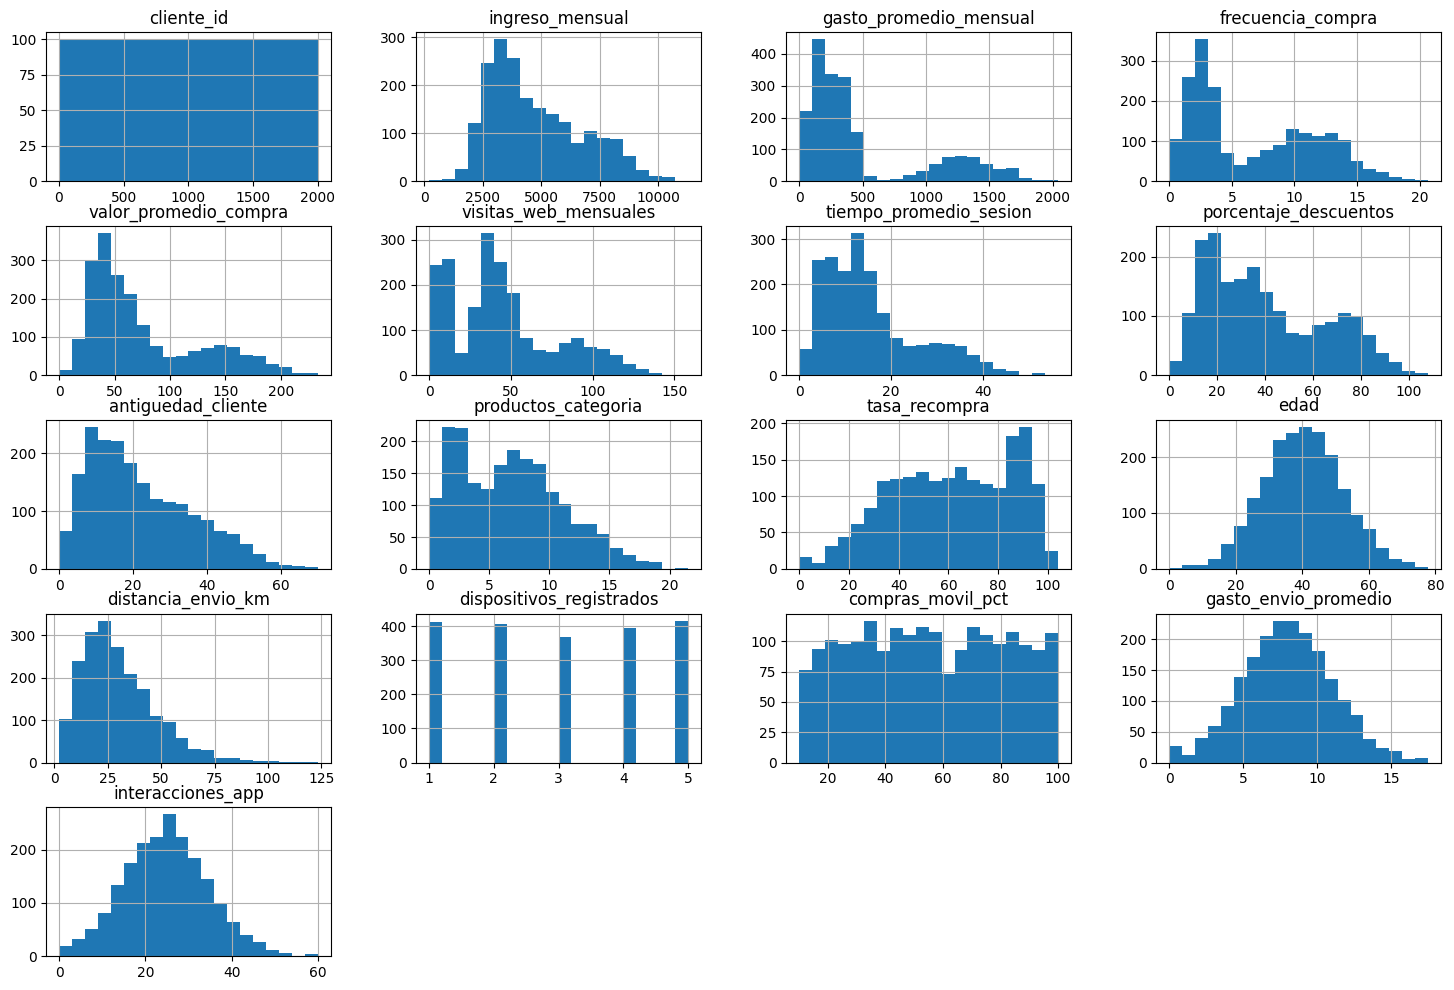

In [246]:
#Distribución de variables

data.hist(
figsize=(18,12),
bins=20
)

plt.show()

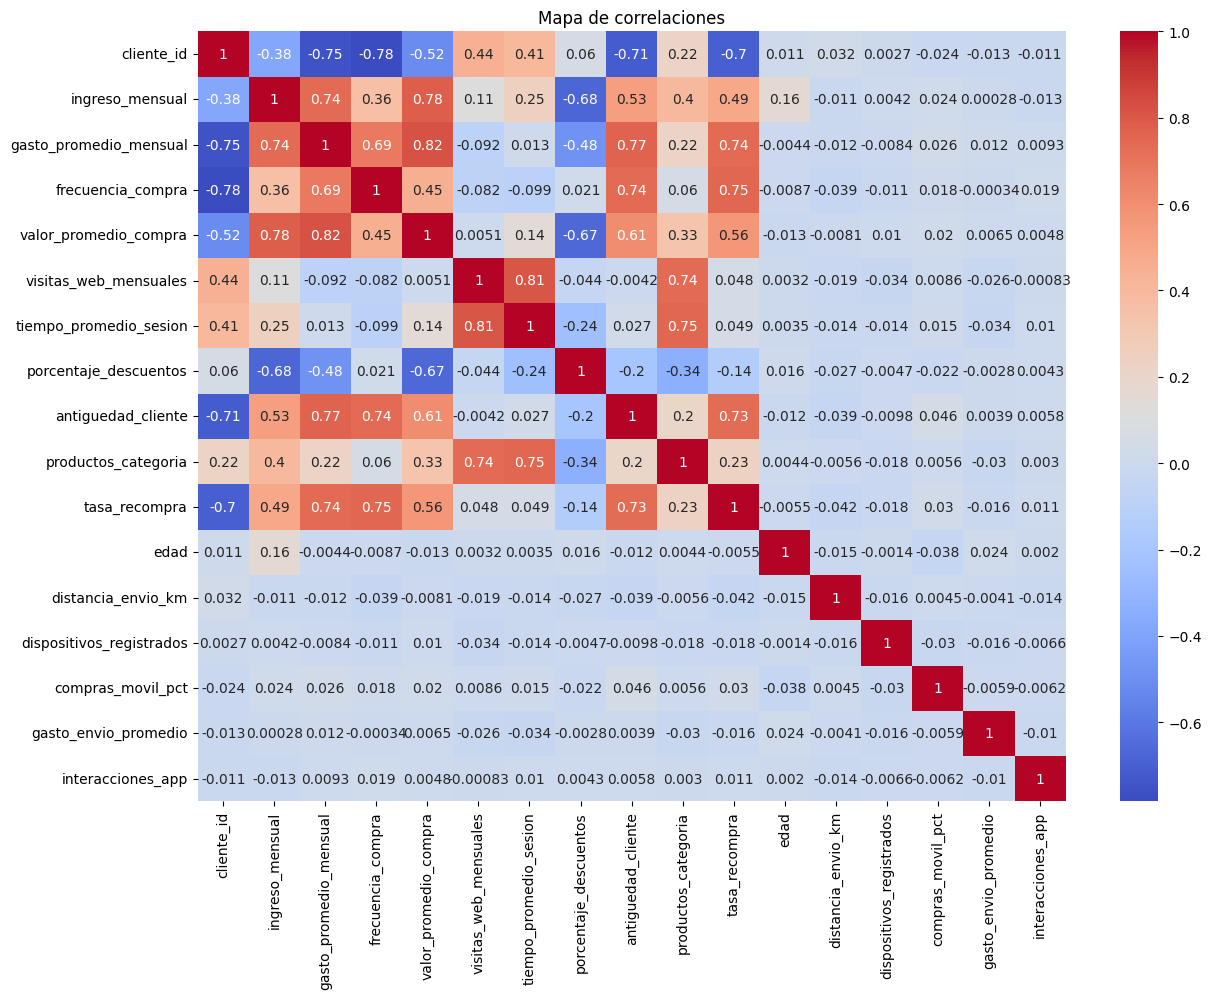

In [247]:
#Análisis de correlación

plt.figure(figsize=(14,10))

sns.heatmap(
data.corr(numeric_only=True),
annot=True,
cmap="coolwarm"
)

plt.title("Mapa de correlaciones")

plt.show()

Se construye un mapa de calor de correlaciones para estudiar la relación lineal entre las variables del conjunto de datos.

#**Deteccion**



In [248]:
display(data.dtypes)

cliente_id                    int64
ingreso_mensual             float64
gasto_promedio_mensual      float64
frecuencia_compra           float64
valor_promedio_compra       float64
visitas_web_mensuales       float64
tiempo_promedio_sesion      float64
porcentaje_descuentos       float64
antiguedad_cliente          float64
productos_categoria         float64
tasa_recompra               float64
edad                        float64
distancia_envio_km          float64
dispositivos_registrados      int64
compras_movil_pct           float64
gasto_envio_promedio        float64
interacciones_app           float64
dtype: object

-**Justificacion**


Se realiza una exploración inicial del dataset para comprender su tamaño, tipos de variables y comportamiento general.

data.shape permite conocer la cantidad de registros y variables disponibles.

data.info() permite identificar tipos de datos y posibles valores nulos.

data.describe() entrega estadísticas descriptivas que ayudan a entender la distribución general de las variables numéricas.

In [249]:

print(f'Dimensiones del dataset: {data.shape}')
print(f'Filas: {data.shape[0]} | Columnas: {data.shape[1]}')


Dimensiones del dataset: (2000, 17)
Filas: 2000 | Columnas: 17


In [250]:
print("\nValores duplicados")
duplicados = data[data.duplicated(keep=False)]
total_duplicados = duplicados.shape[0]
display(duplicados)
print(f"Cantidad de registros duplicados: {total_duplicados}")
if total_duplicados>0:
    data = data_raw.drop_duplicates()


Valores duplicados


,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app


Cantidad de registros duplicados: 0


## **Detección de Inconsistencias**

In [251]:
MIN_EDAD = 12
MAX_EDAD = 100

MIN_DESCUENTO = 0
MAX_DESCUENTO = 100

data = data.drop(columns='cliente_id')

In [252]:

def detect_inconsistencias(info):
    return info[(
    (info['ingreso_mensual']<0)|
    (info['gasto_promedio_mensual']<0)|
    (info['frecuencia_compra']<0)|
    (info['valor_promedio_compra']<0)|
    (info['visitas_web_mensuales']<0)|
    (info['tiempo_promedio_sesion']<0)|
    (info['antiguedad_cliente']<0)|
    (info['productos_categoria']<0)|
    # La tasa es un porcentaje
    (info['distancia_envio_km']<0)|
    (info['dispositivos_registrados']<0)|
    (info['gasto_envio_promedio']<0)|
    (info['interacciones_app']<0)|
    (info['porcentaje_descuentos']<MIN_DESCUENTO)| (info['porcentaje_descuentos']>MAX_DESCUENTO)|
    (info['compras_movil_pct']<0)| (info['compras_movil_pct']>100)|
    (info['tasa_recompra']<0)| (info['tasa_recompra']>100)|
    (info['edad']<MIN_EDAD)| (info['edad']>MAX_EDAD)


)]

def detect_inconsistencias_logicas(info):
    return info[(
    #--RELACION ENTRE VARIABLES--#
    #Suponiendo que la antiguedad entregada sea en meses
    (info["antiguedad_cliente"] > info["edad"]*12) |

    # No se aclara en el enunciado si los dispositivos registrados incluyen móviles,
    # por lo que se considera que puede haber compras móviles aunque haya un solo dispositivo registrado.
    #((info['compras_movil_pct']>0) & (info['dispositivos_registrados']>1))|

    # Se considera inconsistente que haya compras móviles si no hay dispositivos registrados
    ((info['compras_movil_pct']>0) & (info['dispositivos_registrados']<1))|

    # No puede haber uso de la app sin dispositivos
    ((info["interacciones_app"] > 0) & (info["dispositivos_registrados"] == 0)) |

    # Si nunca compra, no debería existir gasto promedio
    ((info["frecuencia_compra"] == 0) & (info["gasto_promedio_mensual"] > 0)) |

    # Si nunca compra, no debería haber categorías compradas
    ((info["frecuencia_compra"] == 0) & (info["productos_categoria"] > 0)) |


    # Si nunca visita el sitio web, el tiempo de sesión debería ser 0
    # Se considerará que las visitas web son un promedio mensual en todo el tiempo registrado,
    # por lo que no se considerará incosistente si no hay tiempo de sesion
    # ((info["visitas_web_mensuales"] == 0) & (info["tiempo_promedio_sesion"] > 0))  |

    # Si nunca compra, no debería existir gasto de envío
    ((info["frecuencia_compra"] == 0) & (info["gasto_envio_promedio"] > 0))
)]

def show_inconsistencias(info):
    inconsist = detect_inconsistencias(info)
    print("Registros inconsistentes encontrados: ")
    display(inconsist)
    print(f"Cantidad de registros inconsistentes: {inconsist.shape[0]}")
    return inconsist

def show_inconsistencias_logicas(info):
    inconsist = detect_inconsistencias_logicas(info)
    print(f"\nRegistros con inconsistencias lógicas: {inconsist.shape[0]}")
    display(inconsist)

    return inconsist


In [253]:
inconsistencias = show_inconsistencias(data)
mask = show_inconsistencias_logicas(data)

Registros inconsistentes encontrados: 


,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
27,2803.465843,450.836849,12.231985,39.252112,42.523490,12.434121,64.079340,20.069325,6.090358,78.008696,11.991651,19.805463,4,36.035822,11.183610,25.989753
92,4559.129176,1306.812417,13.401483,194.819301,44.721462,18.631041,13.438931,26.748921,8.369015,86.035974,10.591292,24.753767,4,85.748034,8.900349,16.755340
178,2724.615501,364.274085,12.727899,20.321362,56.072414,12.890680,68.076560,25.751130,5.768169,53.768634,7.141275,28.778339,5,36.774820,0.771971,15.065762
202,6637.607866,1082.144819,4.427319,162.644434,37.272681,13.087633,13.649721,34.751647,6.424042,100.031141,31.376079,9.825170,1,84.537062,1.439522,20.583932
259,4122.177680,131.958569,1.791368,69.118958,9.846562,2.671404,74.475755,9.955225,1.993007,54.904323,5.216807,13.039711,5,88.574513,10.335356,23.516213
260,9306.655972,1167.637270,13.018507,184.570638,41.583848,20.042420,9.633875,48.189883,7.345028,100.111469,58.066560,4.078692,5,10.070770,6.846475,22.376245
268,7193.191299,860.748877,9.302964,158.255734,47.731993,22.468772,19.402434,40.641741,8.004879,102.574606,36.931913,46.309436,1,22.369594,14.219347,34.598081
286,8452.696166,1033.694838,13.522455,154.522563,33.104413,8.874103,15.208382,55.838290,10.076687,102.395182,49.526962,34.372019,1,82.479150,13.178286,13.958215
306,3181.950565,113.072422,2.869412,40.645404,10.478276,6.704931,27.508741,11.606872,1.216610,44.539951,9.709277,27.952604,4,71.046986,6.264489,31.078941
309,9465.419973,1297.608984,18.318098,159.673892,36.763446,13.192619,19.265716,41.092771,4.946608,100.210179,59.654200,25.362926,2,89.265676,7.684978,17.695239


Cantidad de registros inconsistentes: 38

Registros con inconsistencias lógicas: 19


,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
529,4259.444943,212.127029,0.000000,34.987233,10.648413,5.603581,35.719882,8.086843,0.542885,21.835104,49.143071,18.242718,3,12.794112,4.636713,29.025450
541,3577.247029,54.077960,0.000000,51.765883,8.671007,7.316123,62.033719,3.309857,2.011438,3.989981,61.674124,30.860130,4,31.381110,6.011907,14.458661
664,2092.181951,24.970788,0.000000,52.942862,7.615100,5.023258,38.828903,9.058884,2.196570,25.964396,43.608481,56.558746,1,74.739496,9.901877,20.128113
763,3109.048259,244.848032,0.000000,78.251675,2.939424,5.658262,20.617044,10.967176,1.767214,46.653621,40.829161,33.157594,5,41.643940,11.790078,17.548616
773,2145.417045,71.723477,0.000000,71.742005,7.376358,4.158110,22.686751,2.227328,2.736860,39.956738,62.319905,87.233248,3,76.272563,6.419494,20.506148
818,3314.492628,120.346562,0.000000,37.719902,7.747151,4.916763,51.956260,10.261760,2.699940,33.173004,42.936937,77.821725,2,51.855829,8.664370,43.252373
1011,2823.486645,84.827940,0.000000,34.659934,6.846975,6.611215,45.816167,4.346466,3.177465,45.342382,40.650643,12.555327,4,30.356494,7.263687,35.075532
1095,5503.131604,400.582325,0.000000,79.851362,97.210959,23.190183,19.842481,18.566269,14.137509,43.453734,44.576195,32.067046,2,15.627044,10.308128,27.440348
1131,3293.518270,1269.664245,14.477262,162.323739,23.535790,13.202989,19.703692,41.554928,7.077222,95.566510,0.000000,20.509302,1,45.434291,7.149302,23.119966
1171,4181.502890,164.991722,0.000000,40.910595,10.136430,5.704753,36.624996,16.590988,1.041838,58.436275,29.666625,88.550678,4,79.803472,5.193178,30.066343


In [254]:
porcentaje_inconsistentes = (100 * (inconsistencias.shape[0]+mask.shape[0]) / data.shape[0]).__round__(2)
print(f"Porcentaje total de registros inconsistentes: {porcentaje_inconsistentes}%")


Porcentaje total de registros inconsistentes: 2.85%


## **Trato de Inconsistencias**

In [255]:
columns_to_correct =  [
    'ingreso_mensual',
    'gasto_promedio_mensual',
    'frecuencia_compra',
    'valor_promedio_compra',
    'visitas_web_mensuales',
    'tiempo_promedio_sesion',
    'antiguedad_cliente',
    'productos_categoria',
    'distancia_envio_km',
    'dispositivos_registrados',
    'gasto_envio_promedio',
    'interacciones_app'
]



In [256]:
for col in columns_to_correct:
    data[col] = data[col].clip(lower=0)

data["compras_movil_pct"] = data["compras_movil_pct"].clip(0,100)
data["tasa_recompra"] = data["tasa_recompra"].clip(0,100)

data["porcentaje_descuentos"] = data["porcentaje_descuentos"].clip(MIN_DESCUENTO,MAX_DESCUENTO)

data["edad"] = data["edad"].clip(MIN_EDAD,MAX_EDAD)


In [257]:
print("\nInconsistencias después de la corrección\n")
inconsistencias = show_inconsistencias(data)


Inconsistencias después de la corrección

Registros inconsistentes encontrados: 


,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app


Cantidad de registros inconsistentes: 0


**Justificacion**

Las variable de inconsistencias general queda vacio y puede quedar solo la de inconsistencias lógicas si es que existían

In [258]:
mask = show_inconsistencias_logicas(data)


Registros con inconsistencias lógicas: 18


,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
529,4259.444943,212.127029,0.0,34.987233,10.648413,5.603581,35.719882,8.086843,0.542885,21.835104,49.143071,18.242718,3,12.794112,4.636713,29.025450
541,3577.247029,54.077960,0.0,51.765883,8.671007,7.316123,62.033719,3.309857,2.011438,3.989981,61.674124,30.860130,4,31.381110,6.011907,14.458661
664,2092.181951,24.970788,0.0,52.942862,7.615100,5.023258,38.828903,9.058884,2.196570,25.964396,43.608481,56.558746,1,74.739496,9.901877,20.128113
763,3109.048259,244.848032,0.0,78.251675,2.939424,5.658262,20.617044,10.967176,1.767214,46.653621,40.829161,33.157594,5,41.643940,11.790078,17.548616
773,2145.417045,71.723477,0.0,71.742005,7.376358,4.158110,22.686751,2.227328,2.736860,39.956738,62.319905,87.233248,3,76.272563,6.419494,20.506148
818,3314.492628,120.346562,0.0,37.719902,7.747151,4.916763,51.956260,10.261760,2.699940,33.173004,42.936937,77.821725,2,51.855829,8.664370,43.252373
1011,2823.486645,84.827940,0.0,34.659934,6.846975,6.611215,45.816167,4.346466,3.177465,45.342382,40.650643,12.555327,4,30.356494,7.263687,35.075532
1095,5503.131604,400.582325,0.0,79.851362,97.210959,23.190183,19.842481,18.566269,14.137509,43.453734,44.576195,32.067046,2,15.627044,10.308128,27.440348
1171,4181.502890,164.991722,0.0,40.910595,10.136430,5.704753,36.624996,16.590988,1.041838,58.436275,29.666625,88.550678,4,79.803472,5.193178,30.066343
1301,1807.770591,91.573946,0.0,12.450270,6.796849,6.626005,53.526544,9.046564,2.866130,53.321252,41.243367,45.351691,1,66.844139,12.802159,13.888667


In [259]:
porcentaje_inconsistentes = (100 * (inconsistencias.shape[0]+mask.shape[0]) / data.shape[0]).__round__(2)
print(f"Porcentaje total de registros inconsistentes: {porcentaje_inconsistentes}%")

Porcentaje total de registros inconsistentes: 0.9%


In [260]:
data = data.drop(mask.index)


In [261]:
mask = show_inconsistencias_logicas(data)
inconsistencias = show_inconsistencias(data)


Registros con inconsistencias lógicas: 0


,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app


Registros inconsistentes encontrados: 


,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app


Cantidad de registros inconsistentes: 0


**Justificacion**

Se revisaron registros duplicados, valores faltantes e inconsistencias. Los valores fuera de rangos válidos (por ejemplo, cantidades negativas o porcentajes fuera de sus límites) fueron corregidos mediante truncamiento (clip), ya que sus límites válidos son conocidos. Las inconsistencias lógicas entre variables, como clientes sin compras pero con gasto registrado o clientes con compras móviles sin dispositivos asociados, no fueron corregidas automáticamente porque no es posible identificar cuál de las variables contiene el error. En estos casos, los registros fueron excluidos del análisis para evitar introducir sesgos en el proceso de clustering.

###Parte 1 – Diseño de las Segmentaciones

In [262]:

scaler = StandardScaler()

X_scaled = scaler.fit_transform(data)

inertias = []
silhouettes = []
for k in range(2,11):

    modelo = KMeans(
        n_clusters=k,
        random_state=29,
        n_init=10
    )

    modelo.fit(X_scaled)

    inertias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(X_scaled, modelo.labels_))

kl = KneeLocator(
    range(2,11),
    inertias,
    curve='convex',
    direction='decreasing'
)

print("K óptimo:", kl.elbow)

K óptimo: 4


####Parte 2 – Preparación de Datos

In [263]:
variables_modelo_1 = [
"gasto_promedio_mensual",
"frecuencia_compra",
"valor_promedio_compra",
"tasa_recompra",
"porcentaje_descuentos"
]

data_modelo_1 = data[variables_modelo_1]

data_modelo_1.head()

,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,tasa_recompra,porcentaje_descuentos
0,282.860357,1.501998,83.492628,73.754991,35.382202
1,1142.034918,12.994762,126.689530,88.099458,6.591670
2,110.452151,1.133691,34.541553,27.918664,64.640916
3,272.545043,10.794984,53.087824,87.894471,68.204386
4,100.472521,3.211919,58.165255,26.307533,55.221767


# Justificación detallada – Modelo 1

gasto_promedio_mensual:
Permite medir el aporte económico del cliente.

frecuencia_compra:
Representa recurrencia y nivel de actividad comercial.

valor_promedio_compra:
Permite distinguir clientes de compras pequeñas o grandes.

tasa_recompra:
Refleja fidelización del cliente.

porcentaje_descuentos:
Permite identificar sensibilidad al precio.

--------------------------------------------------------------


Se seleccionan variables relacionadas con el valor comercial del cliente.

Estas variables permiten analizar cuánto compra el cliente, con qué frecuencia y qué nivel de fidelización presenta.

Se excluyen variables como cliente_id o edad, ya que no aportan información directa sobre el comportamiento de compra.

El objetivo es construir un modelo centrado en la dimensión económica del cliente.

In [264]:
#Preparación de variables para Modelo 2 – Comportamiento Digital

variables_modelo_2 = [
"visitas_web_mensuales",
"tiempo_promedio_sesion",
"interacciones_app",
"compras_movil_pct",
"dispositivos_registrados"
]

data_modelo_2 = data[variables_modelo_2]

data_modelo_2.head()

,visitas_web_mensuales,tiempo_promedio_sesion,interacciones_app,compras_movil_pct,dispositivos_registrados
0,104.421405,31.535726,12.550957,80.800319,5
1,32.051972,21.625307,27.013043,57.230176,1
2,8.823966,5.316392,35.003213,64.785633,2
3,28.065438,13.903965,24.480341,31.899143,3
4,7.454023,5.697755,38.423139,90.250141,5


# Justificación detallada – Modelo 2

visitas_web_mensuales:
Representa nivel de interés por la plataforma.

tiempo_promedio_sesion:
Permite medir permanencia y compromiso.

interacciones_app:
Refleja participación digital.

compras_movil_pct:
Mide preferencia por dispositivos móviles.

dispositivos_registrados:
Permite observar diversidad de acceso.

Variables como edad, ingreso_mensual, distancia_envio_km y gasto_envio_promedio fueron excluidas porque no representan directamente las dimensiones seleccionadas y podrían introducir ruido en el agrupamiento.



Se seleccionan variables relacionadas con el comportamiento digital del cliente.

Estas variables permiten analizar cómo interactúa el usuario con la plataforma, incluyendo navegación web, uso de la aplicación y dispositivos asociados.

Se excluyen variables de compra directa como gasto o frecuencia, ya que no representan el objetivo de este enfoque.

In [265]:
#Verificación de escalas – Modelo 1

data_modelo_1.describe().round(2)



,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,tasa_recompra,porcentaje_descuentos
count,1982.00,1982.00,1982.00,1982.00,1982.00
mean,509.94,6.81,75.24,61.60,40.22
std,491.75,4.87,49.99,24.05,24.45
min,0.00,0.01,0.00,0.00,0.00
25%,163.66,2.49,37.56,42.48,19.26
50%,306.93,4.85,56.93,63.27,34.68
75%,715.20,10.97,105.39,84.28,60.91
max,2040.95,20.69,233.28,100.00,100.00


Se analizan las estadísticas descriptivas del primer conjunto de variables para identificar diferencias de escala entre ellas antes de aplicar el proceso de estandarización.

In [266]:
#Verificación de escalas – Modelo 2

data_modelo_2.describe().round(2)

,visitas_web_mensuales,tiempo_promedio_sesion,interacciones_app,compras_movil_pct,dispositivos_registrados
count,1982.00,1982.00,1982.00,1982.00,1982.00
mean,45.14,15.62,24.84,55.62,3.00
std,32.19,10.37,9.82,25.52,1.44
min,0.00,0.00,0.00,10.07,1.00
25%,18.26,7.70,18.14,34.05,2.00
50%,39.41,13.07,24.82,54.93,3.00
75%,60.67,20.24,31.27,77.69,4.00
max,158.31,56.26,59.99,100.00,5.00


In [267]:
#Escalamiento Modelo 1

scaler_modelo_1 = StandardScaler()

X_modelo_1 = scaler_modelo_1.fit_transform(
data_modelo_1
)

Se aplica StandardScaler para estandarizar las variables del modelo.

Esto es necesario porque K-Means utiliza distancias euclidianas, y variables con diferentes escalas podrían dominar el resultado del clustering.

La estandarización asegura que todas las variables contribuyan de manera equilibrada al modelo.

In [268]:
#Escalamiento Modelo 2

scaler_modelo_2 = StandardScaler()

X_modelo_2 = scaler_modelo_2.fit_transform(
data_modelo_2
)

Se aplica el mismo proceso de estandarización al segundo conjunto de variables.

Esto garantiza consistencia metodológica entre ambos modelos y evita sesgos por diferencias de escala entre variables de comportamiento digital.

In [269]:
#Visualización después del escalado

pd.DataFrame(
X_modelo_1,
columns=variables_modelo_1
).describe().round(2)

pd.DataFrame(
X_modelo_2,
columns=variables_modelo_2
).describe().round(2)

,visitas_web_mensuales,tiempo_promedio_sesion,interacciones_app,compras_movil_pct,dispositivos_registrados
count,1982.00,1982.00,1982.00,1982.00,1982.00
mean,0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-1.40,-1.51,-2.53,-1.79,-1.39
25%,-0.84,-0.76,-0.68,-0.85,-0.69
50%,-0.18,-0.25,-0.00,-0.03,0.00
75%,0.48,0.45,0.65,0.87,0.70
max,3.52,3.92,3.58,1.74,1.40


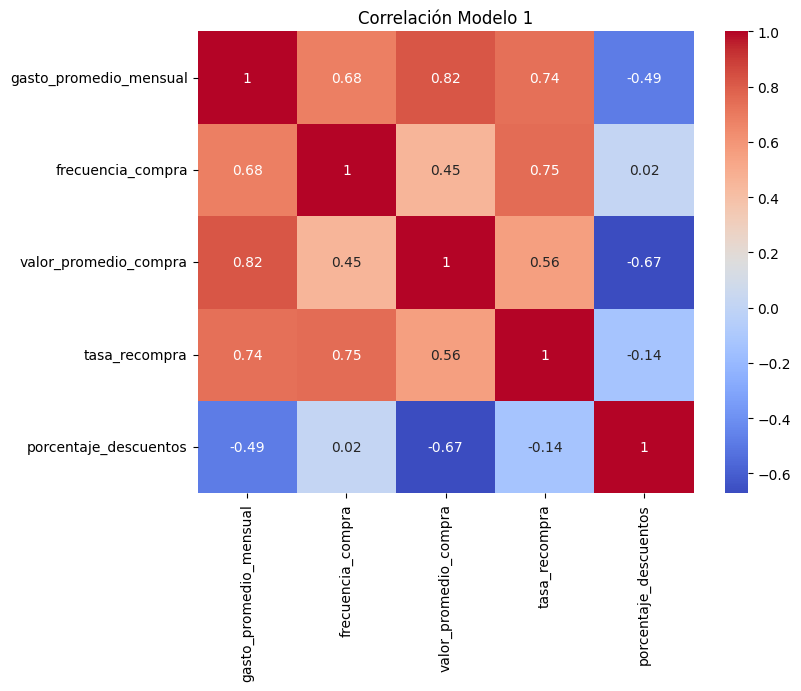

In [270]:
#Análisis de correlación – Modelo 1

plt.figure(figsize=(8,6))

sns.heatmap(
data_modelo_1.corr(),
annot=True,
cmap="coolwarm"
)

plt.title(
"Correlación Modelo 1"
)

plt.show()

In [271]:
data_modelo_1.corr().round(2)

,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,tasa_recompra,porcentaje_descuentos
gasto_promedio_mensual,1.00,0.68,0.82,0.74,-0.49
frecuencia_compra,0.68,1.00,0.45,0.75,0.02
valor_promedio_compra,0.82,0.45,1.00,0.56,-0.67
tasa_recompra,0.74,0.75,0.56,1.00,-0.14
porcentaje_descuentos,-0.49,0.02,-0.67,-0.14,1.00


Se analizó la correlación entre las variables del primer modelo para identificar posibles relaciones fuertes o variables redundantes antes de construir el modelo de clustering.

Se observa una correlación positiva alta entre gasto_promedio_mensual y valor_promedio_compra (0.82), indicando que los clientes que gastan más al mes también suelen realizar compras de mayor valor. Asimismo, frecuencia_compra y tasa_recompra presentan una correlación de 0.75, lo que refleja que quienes compran con mayor frecuencia tienden también a repetir sus compras.

Por otra parte, porcentaje_descuentos presenta correlaciones negativas con gasto_promedio_mensual (-0.48) y especialmente con valor_promedio_compra (-0.67), lo que sugiere que los clientes que utilizan mayores descuentos suelen realizar compras de menor valor.

Aunque existen algunas correlaciones relativamente altas, ninguna supera valores cercanos a 0.90, por lo que no se consideró que existiera redundancia suficiente para eliminar variables. Cada una aporta información distinta sobre el comportamiento comercial del cliente y contribuye a una mejor segmentación.

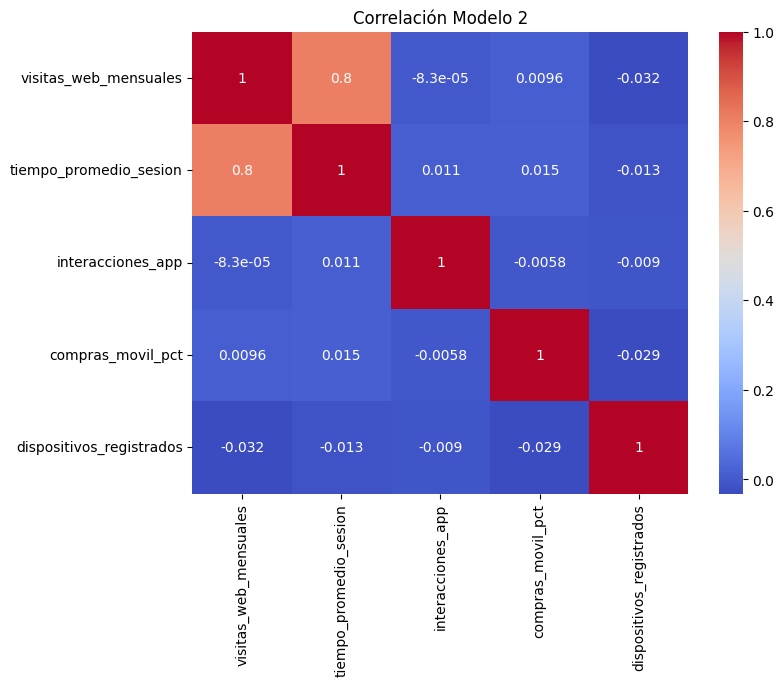

In [272]:
#Análisis de correlación – Modelo 2

plt.figure(figsize=(8,6))

sns.heatmap(
data_modelo_2.corr(),
annot=True,
cmap="coolwarm"
)

plt.title(
"Correlación Modelo 2"
)

plt.show()

In [273]:
data_modelo_2.corr().round(2)

,visitas_web_mensuales,tiempo_promedio_sesion,interacciones_app,compras_movil_pct,dispositivos_registrados
visitas_web_mensuales,1.00,0.80,-0.00,0.01,-0.03
tiempo_promedio_sesion,0.80,1.00,0.01,0.02,-0.01
interacciones_app,-0.00,0.01,1.00,-0.01,-0.01
compras_movil_pct,0.01,0.02,-0.01,1.00,-0.03
dispositivos_registrados,-0.03,-0.01,-0.01,-0.03,1.00


En el segundo modelo se analizaron las relaciones entre las variables que describen el comportamiento digital de los clientes.

La mayor correlación observada corresponde a visitas_web_mensuales y tiempo_promedio_sesion (0.81), indicando que los clientes que visitan con mayor frecuencia el sitio web también permanecen más tiempo navegando.

Las demás variables presentan correlaciones muy cercanas a cero, lo que indica que aportan información independiente y describen distintos aspectos del comportamiento digital.

Debido a que únicamente existe una correlación alta y el resto de las variables aportan información complementaria, se decidió conservar todas las variables para el modelo de segmentación.

Se estudia la distribución de las variables seleccionadas para detectar posibles problemas antes de construir el modelo.

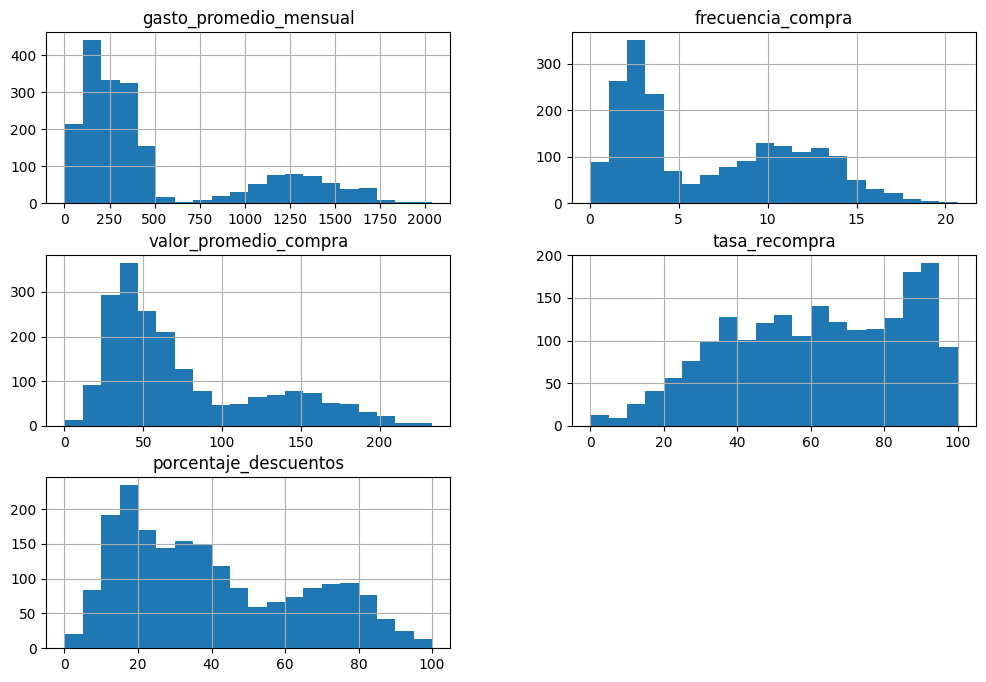

In [274]:
#Distribución de variables – Modelo 1

data_modelo_1.hist(
figsize=(12,8),
bins=20
)

plt.show()



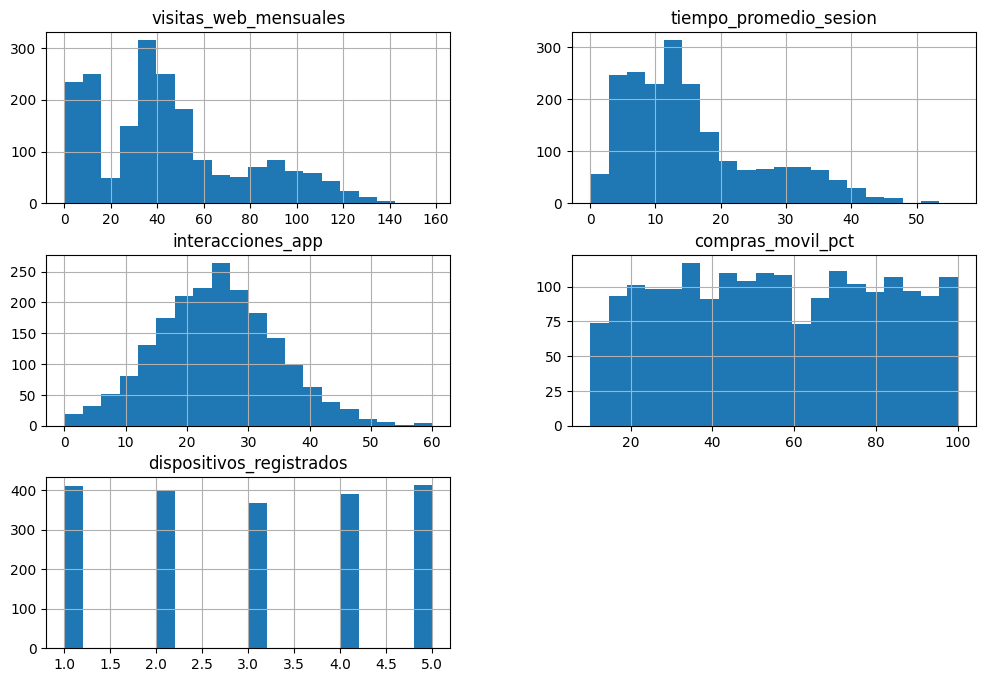

In [275]:
#Distribución de variables – Modelo 2

data_modelo_2.hist(
figsize=(12,8),
bins=20
)

plt.show()

Se estudia la distribución de las variables seleccionadas para detectar posibles problemas antes de construir el modelo.

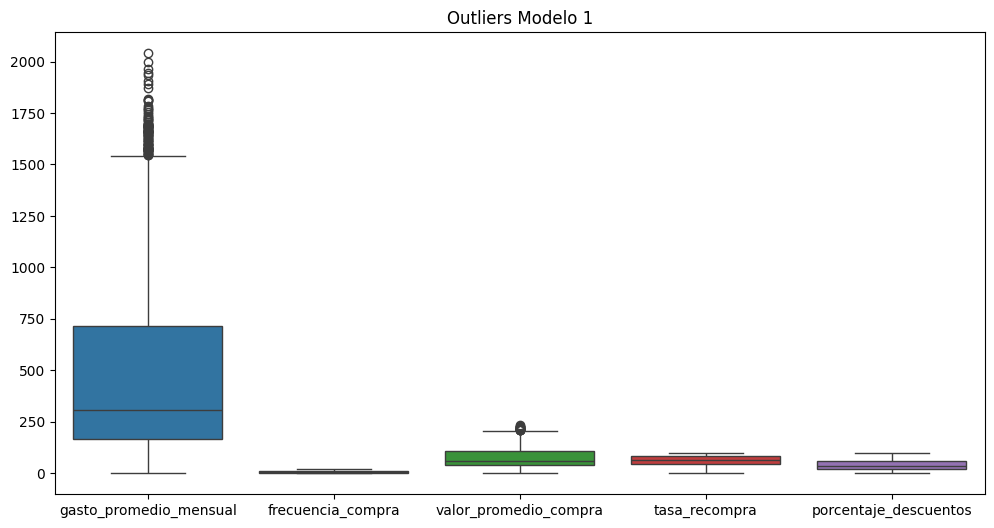

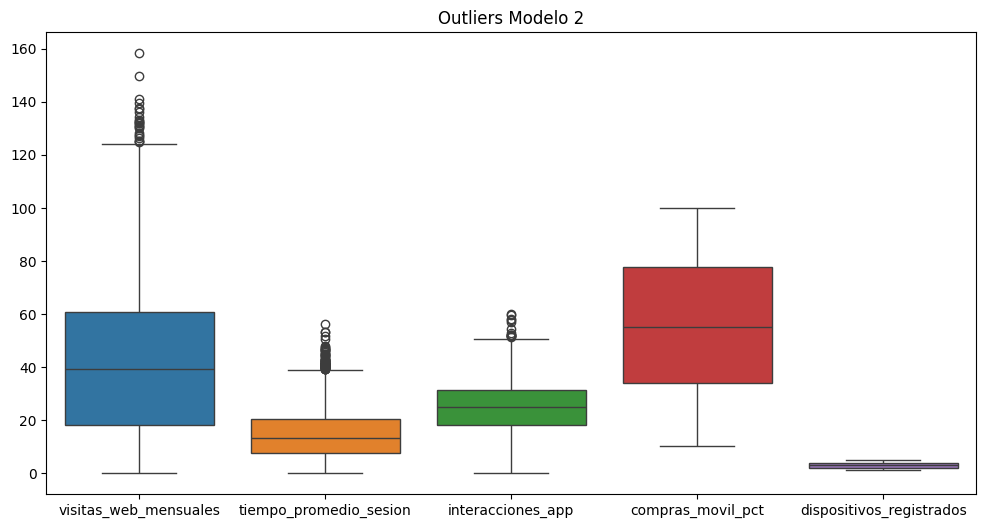

In [276]:
#Detección visual de valores atípicos

plt.figure(
figsize=(12,6)
)

sns.boxplot(
data=data_modelo_1
)

plt.title(
"Outliers Modelo 1"
)

plt.show()

plt.figure(
figsize=(12,6)
)

sns.boxplot(
data=data_modelo_2
)

plt.title(
"Outliers Modelo 2"
)

plt.show()

In [277]:
data_modelo_1.describe().round(2)

,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,tasa_recompra,porcentaje_descuentos
count,1982.00,1982.00,1982.00,1982.00,1982.00
mean,509.94,6.81,75.24,61.60,40.22
std,491.75,4.87,49.99,24.05,24.45
min,0.00,0.01,0.00,0.00,0.00
25%,163.66,2.49,37.56,42.48,19.26
50%,306.93,4.85,56.93,63.27,34.68
75%,715.20,10.97,105.39,84.28,60.91
max,2040.95,20.69,233.28,100.00,100.00


In [278]:
data_modelo_2.describe().round(2)

,visitas_web_mensuales,tiempo_promedio_sesion,interacciones_app,compras_movil_pct,dispositivos_registrados
count,1982.00,1982.00,1982.00,1982.00,1982.00
mean,45.14,15.62,24.84,55.62,3.00
std,32.19,10.37,9.82,25.52,1.44
min,0.00,0.00,0.00,10.07,1.00
25%,18.26,7.70,18.14,34.05,2.00
50%,39.41,13.07,24.82,54.93,3.00
75%,60.67,20.24,31.27,77.69,4.00
max,158.31,56.26,59.99,100.00,5.00


Se utilizan diagramas de caja para identificar la presencia de valores atípicos en las variables seleccionadas.

Los outliers no fueron eliminados, ya que pueden representar comportamientos reales de clientes con patrones extremos de compra o uso de la plataforma.

####Parte 3 – Construcción de Modelos de Clustering

Antes de construir los modelos de clustering, fue necesario preparar los datos para asegurar que todas las variables aportaran de manera equilibrada al algoritmo K-Means.

Para cada modelo se seleccionaron únicamente las variables relacionadas con la dimensión de análisis correspondiente. Posteriormente, se aplicó StandardScaler para estandarizar las variables, logrando que todas tuvieran una media cercana a 0 y una desviación estándar cercana a 1.

Este proceso evita que variables con valores numéricamente mayores tengan una influencia excesiva sobre el cálculo de las distancias euclidianas utilizadas por K-Means.

#Modelo 1

In [279]:
# Modelo 1 – Valor Comercial

inertias_modelo_1 = []

silhouettes_modelo_1 = []

rango_k = range(2, 11)

for k in rango_k:

    modelo = KMeans(
        n_clusters=k,
        random_state=29
    )

    modelo.fit(
        X_modelo_1
    )

    inertias_modelo_1.append(
        modelo.inertia_
    )

    silhouettes_modelo_1.append(
        silhouette_score(
            X_modelo_1,
            modelo.labels_
        )
    )

Justificación

En esta celda se entrenan varios modelos K-Means utilizando distintos valores de k (desde 2 hasta 10).

Para cada modelo se calcula la inercia, que mide qué tan compactos son los clusters, y el índice Silhouette, que evalúa simultáneamente la cohesión interna y la separación entre los grupos.

Estas métricas permiten comparar distintas alternativas y seleccionar posteriormente un número adecuado de clusters para el Modelo 1.

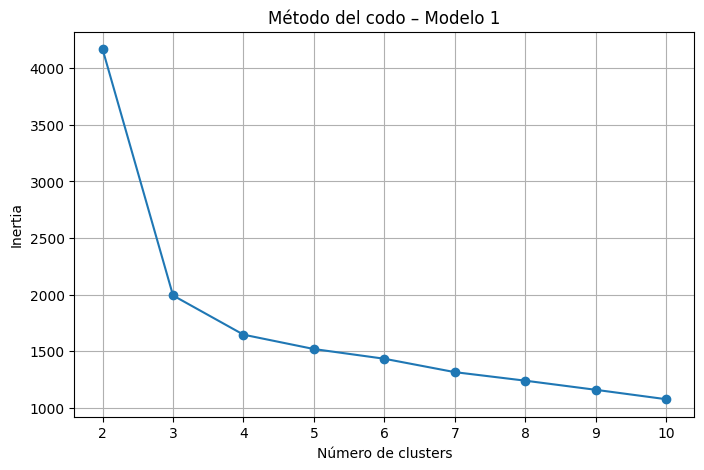

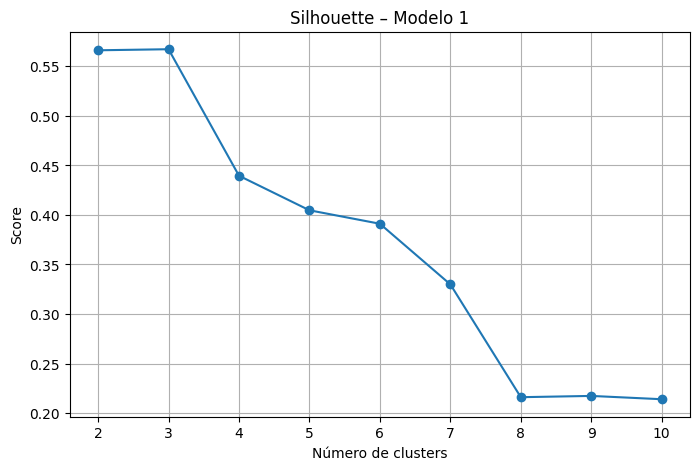

In [280]:
# Curva del codo

plt.figure(figsize=(8,5))

plt.plot(
    rango_k,
    inertias_modelo_1,
    marker="o"
)

plt.title(
    "Método del codo – Modelo 1"
)

plt.xlabel(
    "Número de clusters"
)

plt.ylabel(
    "Inertia"
)

plt.grid()

plt.show()


# Silhouette

plt.figure(figsize=(8,5))

plt.plot(
    rango_k,
    silhouettes_modelo_1,
    marker="o"
)

plt.title(
    "Silhouette – Modelo 1"
)

plt.xlabel(
    "Número de clusters"
)

plt.ylabel(
    "Score"
)

plt.grid()

plt.show()



**Justificacion**


Se construye la curva de inercias para visualizar cómo disminuye la variabilidad interna de los clusters al aumentar el número de grupos.

El objetivo es identificar el denominado método del codo, es decir, el punto donde agregar nuevos clusters produce mejoras cada vez menores.

y tambien Se grafica el índice Silhouette para comparar la calidad del agrupamiento obtenida con distintos valores de k.

Esta métrica complementa al método del codo y ayuda a seleccionar un número de clusters que no solo sea compacto, sino también bien separado.

In [281]:
# Selección automática

knee_1 = KneeLocator(
    rango_k,
    inertias_modelo_1,
    curve="convex",
    direction="decreasing"
)

print(
    "K óptimo Modelo 1:",
    knee_1.elbow
)


# Entrenamiento final

kmeans_modelo_1 = KMeans(
    n_clusters=knee_1.elbow,
    random_state=29
)

clusters_modelo_1 = kmeans_modelo_1.fit_predict(
    X_modelo_1
)

data["cluster_modelo_1"] = clusters_modelo_1


# Resumen de clusters

data.groupby(
    "cluster_modelo_1"
)[
    variables_modelo_1
].mean().round(2)

K óptimo Modelo 1: 3


,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,tasa_recompra,porcentaje_descuentos
cluster_modelo_1,,,,,
0,183.51,2.52,56.97,42.63,35.57
1,1305.32,12.08,151.15,90.27,14.93
2,356.35,10.01,35.14,70.30,74.80


Una vez determinado el número adecuado de clusters, se entrena el modelo definitivo de K-Means.

Cada cliente queda asignado a un grupo, almacenando la etiqueta correspondiente en una nueva columna del conjunto de datos para facilitar su posterior análisis e interpretación.

Estos valores permiten caracterizar cada segmento y comprender las principales diferencias existentes entre los grupos obtenidos.

In [282]:
print(
    f"Silhouette Score: {
        silhouette_score(
            X_modelo_1,
            data['cluster_modelo_1']
        ).__round__(4)
    }"
)

Silhouette Score: 0.5672


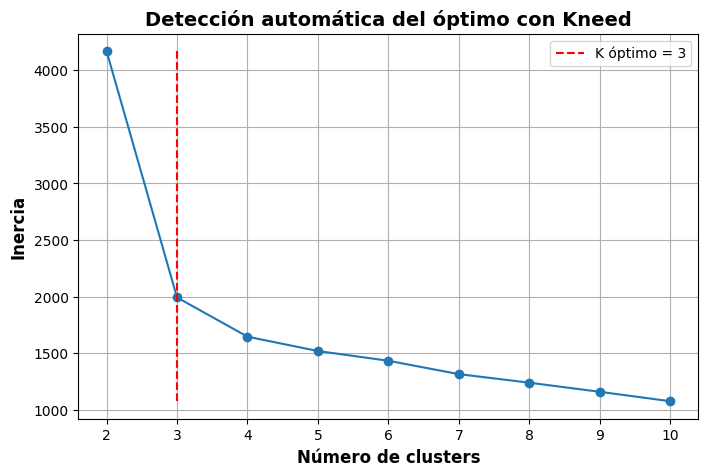

In [283]:
# Curva de inercias Modelo 1

plt.figure(figsize=(8,5))

plt.plot(
    rango_k,
    inertias_modelo_1,
    marker="o"
)

plt.vlines(
    knee_1.elbow,
    min(inertias_modelo_1),
    max(inertias_modelo_1),
    colors="red",
    linestyles="--",
    label=f"K óptimo = {knee_1.elbow}"
)

plt.xlabel(
    "Número de clusters",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Inercia",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "Detección automática del óptimo con Kneed",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid()

plt.show()

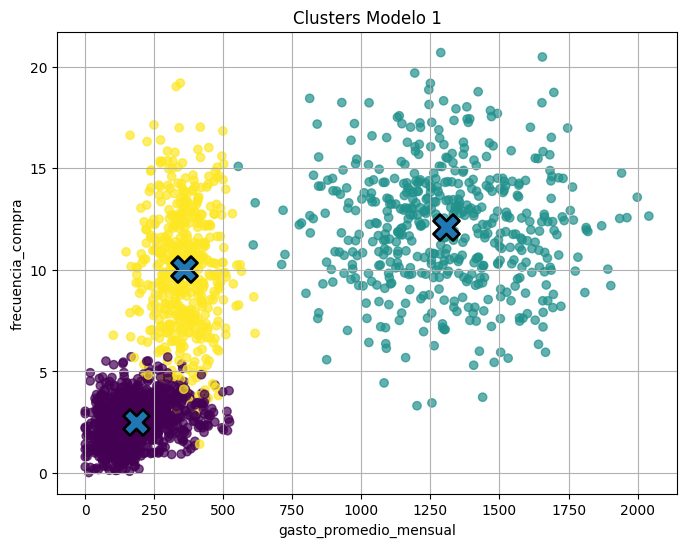

In [284]:
# Visualización Modelo 1 con centroides

col_x = variables_modelo_1[0]
col_y = variables_modelo_1[1]

plt.figure(
    figsize=(8,6)
)

plt.scatter(

    data[col_x],

    data[col_y],

    c=data["cluster_modelo_1"],

    alpha=0.7

)


# Obtener centroides

centroides = kmeans_modelo_1.cluster_centers_

centroides_originales = scaler_modelo_1.inverse_transform(
    centroides
)


# Dibujar centroides

plt.scatter(

    centroides_originales[:,0],

    centroides_originales[:,1],

    marker="X",

    s=350,

    edgecolor="black",

    linewidth=2

)


plt.xlabel(
    col_x
)

plt.ylabel(
    col_y
)

plt.title(
    "Clusters Modelo 1"
)

plt.grid()

plt.show()

**Justificación**

Para determinar el número adecuado de clusters se utilizaron dos métricas.

Método del codo (Inertia):
Permite observar el punto donde agregar nuevos grupos deja de generar mejoras importantes.

Índice Silhouette:
Permite medir separación y compactación entre grupos.

Se seleccionó el valor de k que entregó el mejor equilibrio entre interpretabilidad y calidad del agrupamiento.

In [285]:
# PCA para visualizar el Modelo 1

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_modelo_1)

print(
    "Varianza explicada:",
    pca.explained_variance_ratio_
)

Varianza explicada: [0.64147928 0.24976307]


Las dos primeras componentes principales explican aproximadamente el 89% de la variabilidad de los datos (64.1% + 25.0%), por lo que la representación bidimensional es adecuada para visualizar los clusters obtenidos.

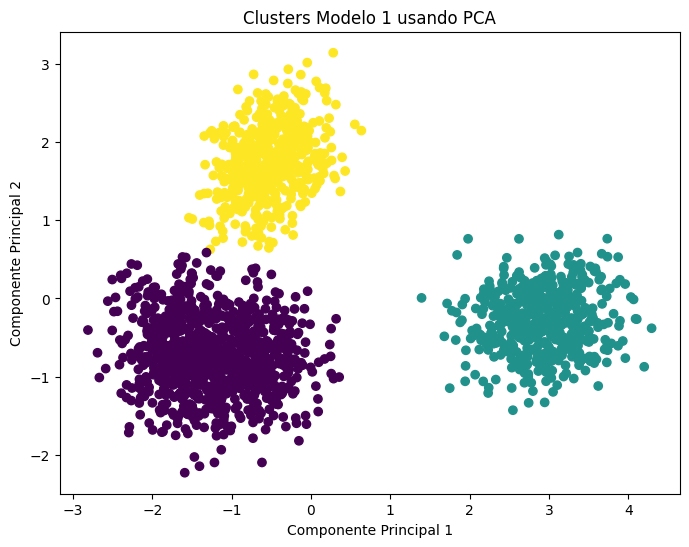

In [286]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=data["cluster_modelo_1"],
    cmap="viridis"
)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Clusters Modelo 1 usando PCA")

plt.show()

#Modelo 2

In [287]:
# Modelo 2 – Comportamiento Digital
# Buscar mejor valor de K

inertias_modelo_2 = []

silhouettes_modelo_2 = []

rango_k = range(2, 11)

for k in rango_k:

    modelo = KMeans(
        n_clusters=k,
        random_state=29
    )

    modelo.fit(X_modelo_2)

    inertias_modelo_2.append(
        modelo.inertia_
    )

    silhouettes_modelo_2.append(
        silhouette_score(
            X_modelo_2,
            modelo.labels_
        )
    )


Se repite el procedimiento anterior utilizando las variables correspondientes al comportamiento digital.

De esta forma se construye un segundo modelo independiente que permitirá comparar ambas perspectivas de segmentación.

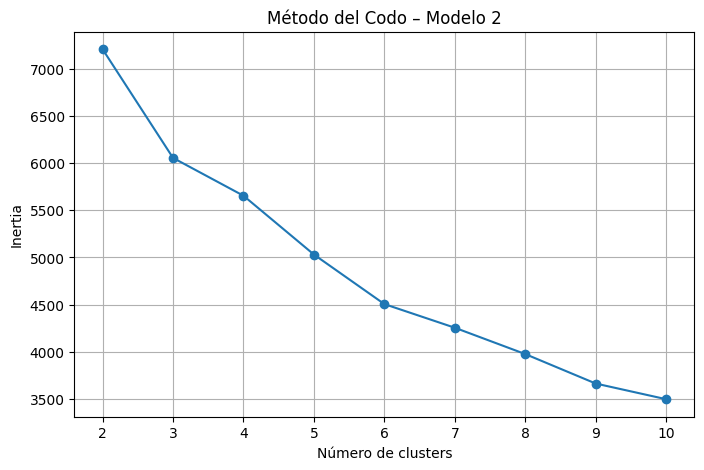

In [288]:
# Curva del codo

plt.figure(figsize=(8,5))

plt.plot(
    rango_k,
    inertias_modelo_2,
    marker="o"
)

plt.title(
    "Método del Codo – Modelo 2"
)

plt.xlabel(
    "Número de clusters"
)

plt.ylabel(
    "Inertia"
)

plt.grid()

plt.show()






Se analiza nuevamente la curva de inercias para determinar el número adecuado de clusters dentro del segundo conjunto de variables.

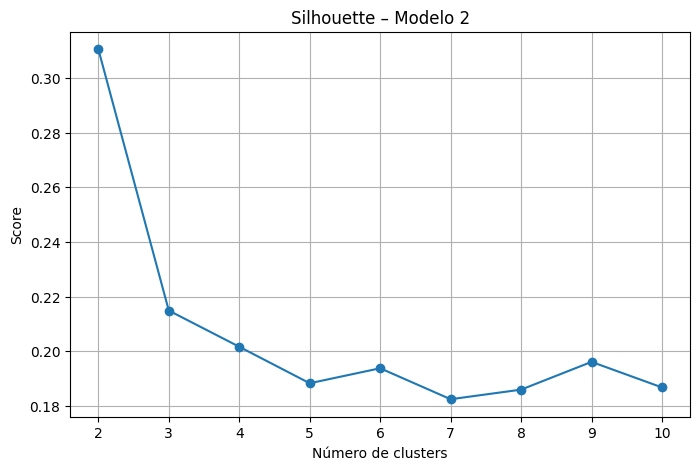

In [289]:
# Índice Silhouette

plt.figure(figsize=(8,5))

plt.plot(
    rango_k,
    silhouettes_modelo_2,
    marker="o"
)

plt.title(
    "Silhouette – Modelo 2"
)

plt.xlabel(
    "Número de clusters"
)

plt.ylabel(
    "Score"
)

plt.grid()

plt.show()



In [290]:
# Selección automática de K

knee_2 = KneeLocator(
    rango_k,
    inertias_modelo_2,
    curve="convex",
    direction="decreasing"
)

k_optimo = knee_2.elbow


# Respaldo si no encuentra codo

if k_optimo is None:
    k_optimo = 3


print(
    "K óptimo Modelo 2:",
    k_optimo
)



K óptimo Modelo 2: 6


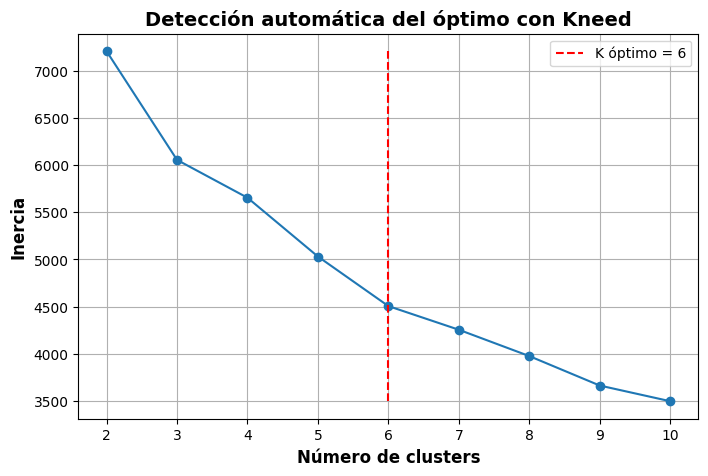

In [291]:
# Curva de inercias Modelo 2

plt.figure(figsize=(8,5))

plt.plot(
    rango_k,
    inertias_modelo_2,
    marker="o"
)

plt.vlines(
    knee_2.elbow,
    min(inertias_modelo_2),
    max(inertias_modelo_2),
    colors="red",
    linestyles="--",
    label=f"K óptimo = {knee_2.elbow}"
)

plt.xlabel(
    "Número de clusters",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Inercia",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "Detección automática del óptimo con Kneed",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.grid()

plt.show()

In [292]:
# Entrenamiento final

kmeans_modelo_2 = KMeans(
    n_clusters=k_optimo,
    random_state=29
)

clusters_modelo_2 = kmeans_modelo_2.fit_predict(
    X_modelo_2
)


# Guardar clusters

data["cluster_modelo_2"] = clusters_modelo_2


# Resumen de segmentos

data.groupby(
    "cluster_modelo_2"
)[
    variables_modelo_2
].mean().round(2)

,visitas_web_mensuales,tiempo_promedio_sesion,interacciones_app,compras_movil_pct,dispositivos_registrados
cluster_modelo_2,,,,,
0,34.05,11.57,34.22,75.47,2.73
1,30.18,11.04,23.98,37.15,4.58
2,92.36,30.62,27.08,63.32,4.29
3,92.75,31.42,22.88,50.22,1.79
4,30.04,10.51,25.10,34.32,1.89
5,28.18,10.48,16.09,77.85,2.90


In [293]:
# Cantidad de clientes por cluster

print("Modelo 1")

print(
    data[
        "cluster_modelo_1"
    ].value_counts()
)

print()

print("Modelo 2")

print(
    data[
        "cluster_modelo_2"
    ].value_counts()
)

Modelo 1
cluster_modelo_1
0    984
1    500
2    498
Name: count, dtype: int64

Modelo 2
cluster_modelo_2
4    402
1    384
0    366
5    365
3    252
2    213
Name: count, dtype: int64


In [294]:
 #Comparación de clusters

resumen_modelo_1 = data.groupby(
    "cluster_modelo_1"
)[
    variables_modelo_1
].mean().round(2)

resumen_modelo_2 = data.groupby(
    "cluster_modelo_2"
)[
    variables_modelo_2
].mean().round(2)


print("MODELO 1")
display(
    resumen_modelo_1
)

print()

print("MODELO 2")
display(
    resumen_modelo_2
)

MODELO 1


,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,tasa_recompra,porcentaje_descuentos
cluster_modelo_1,,,,,
0,183.51,2.52,56.97,42.63,35.57
1,1305.32,12.08,151.15,90.27,14.93
2,356.35,10.01,35.14,70.30,74.80



MODELO 2


,visitas_web_mensuales,tiempo_promedio_sesion,interacciones_app,compras_movil_pct,dispositivos_registrados
cluster_modelo_2,,,,,
0,34.05,11.57,34.22,75.47,2.73
1,30.18,11.04,23.98,37.15,4.58
2,92.36,30.62,27.08,63.32,4.29
3,92.75,31.42,22.88,50.22,1.79
4,30.04,10.51,25.10,34.32,1.89
5,28.18,10.48,16.09,77.85,2.90


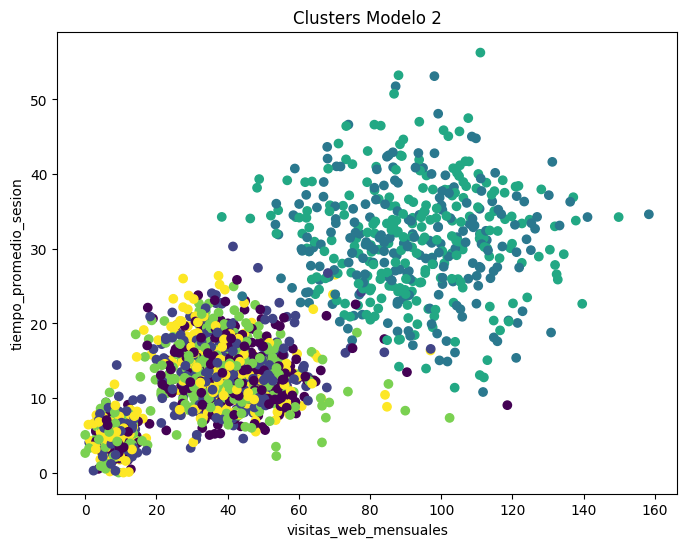

In [295]:
# Visualización Modelo 2

plt.figure(
    figsize=(8,6)
)

plt.scatter(

    data[
        variables_modelo_2[0]
    ],

    data[
        variables_modelo_2[1]
    ],

    c=data[
        "cluster_modelo_2"
    ]

)

plt.xlabel(
    variables_modelo_2[0]
)

plt.ylabel(
    variables_modelo_2[1]
)

plt.title(
    "Clusters Modelo 2"
)

plt.show()

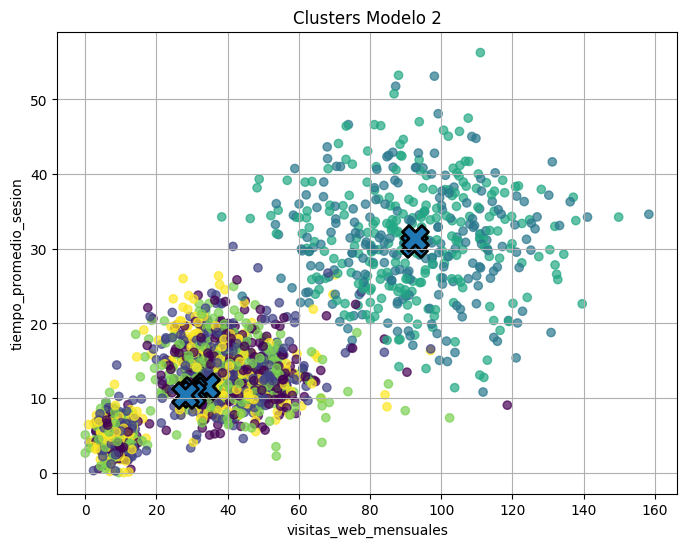

In [296]:
# Visualización Modelo 2 con centroides

col_x = variables_modelo_2[0]
col_y = variables_modelo_2[1]

plt.figure(
    figsize=(8,6)
)

plt.scatter(

    data[col_x],

    data[col_y],

    c=data["cluster_modelo_2"],

    alpha=0.7

)


# Obtener centroides

centroides = kmeans_modelo_2.cluster_centers_

centroides_originales = scaler_modelo_2.inverse_transform(
    centroides
)


# Dibujar centroides

plt.scatter(

    centroides_originales[:,0],

    centroides_originales[:,1],

    marker="X",

    s=350,

    edgecolor="black",

    linewidth=2

)


plt.xlabel(
    col_x
)

plt.ylabel(
    col_y
)

plt.title(
    "Clusters Modelo 2"
)

plt.grid()

plt.show()

In [297]:
# PCA para visualizar el Modelo 2

pca = PCA(n_components=2)

X_pca_modelo_2 = pca.fit_transform(X_modelo_2)

print("Varianza explicada:", pca.explained_variance_ratio_)

Varianza explicada: [0.36127535 0.20550621]


En este caso las dos primeras componentes explican cerca del 56.7% de la variabilidad total. Esto indica que parte importante de la información permanece en dimensiones adicionales, por lo que la visualización en dos dimensiones puede mostrar grupos parcialmente superpuestos, aunque el algoritmo K-Means continúa trabajando sobre las cinco variables originales.

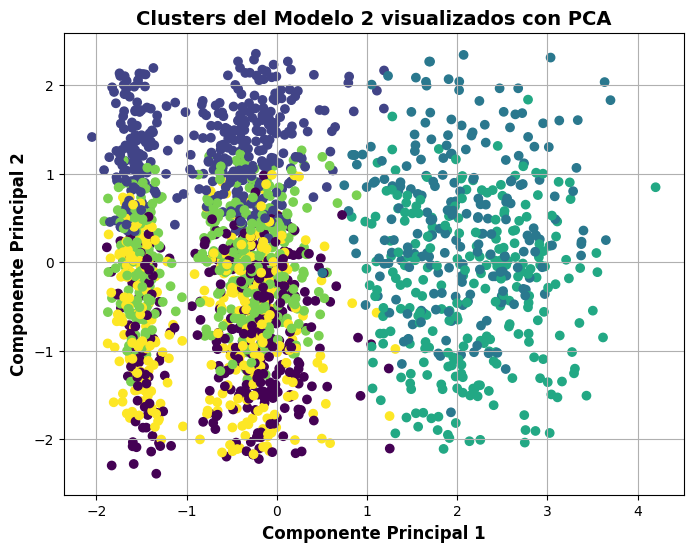

In [298]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_modelo_2[:,0],
    X_pca_modelo_2[:,1],
    c=data["cluster_modelo_2"],
    cmap="viridis"
)

plt.xlabel("Componente Principal 1", fontsize=12, fontweight="bold")
plt.ylabel("Componente Principal 2", fontsize=12, fontweight="bold")
plt.title("Clusters del Modelo 2 visualizados con PCA", fontsize=14, fontweight="bold")

plt.grid(True)

plt.show()

In [299]:
# Métricas finales

print("Modelo 1")
print(
    "Silhouette:",
    round(
        silhouette_score(
            X_modelo_1,
            clusters_modelo_1
        ),
        3
    )
)

print()

print("Modelo 2")
print(
    "Silhouette:",
    round(
        silhouette_score(
            X_modelo_2,
            clusters_modelo_2
        ),
        3
    )
)

Modelo 1
Silhouette: 0.567

Modelo 2
Silhouette: 0.194


In [300]:
print(
    f"Silhouette Score: {
        silhouette_score(
            X_modelo_2,
            data['cluster_modelo_2']
        ).__round__(4)
    }"
)

Silhouette Score: 0.1938



El Modelo 1 obtuvo un valor de 0.567, indicando una separación adecuada entre grupos y una estructura relativamente compacta.

Esto sugiere que las variables asociadas al valor comercial permiten identificar segmentos diferenciados de clientes.

Por otro lado, el Modelo 2 obtuvo un valor de 0.196, indicando una menor separación entre clusters.

Esto puede explicarse porque el comportamiento digital suele presentar mayor variabilidad y superposición entre usuarios.

A pesar de ello, los segmentos obtenidos siguen siendo útiles para comprender patrones generales de interacción con la plataforma.

En términos técnicos, el Modelo 1 presenta una mejor calidad de agrupamiento, mientras que el Modelo 2 aporta una visión complementaria del comportamiento del cliente.

# Criterio de selección

Para seleccionar el número de clusters se utilizaron dos criterios complementarios. El método del codo permitió identificar el punto donde la disminución de la inercia comienza a estabilizarse, indicando que agregar más clusters aporta mejoras cada vez menores. Además, se evaluó el índice Silhouette, el cual mide la cohesión interna y la separación entre los grupos. Finalmente, se seleccionó el valor de K = 3 para el Modelo 1 y K = 6 para el Modelo 2, ya que ofrecían el mejor equilibrio entre calidad del agrupamiento e interpretabilidad de los segmentos.

In [301]:
data[
    "cluster_modelo_1"
].value_counts()

cluster_modelo_1
0    984
1    500
2    498
Name: count, dtype: int64

In [302]:
data.describe()

,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app,cluster_modelo_1,cluster_modelo_2
count,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000
mean,4764.808966,509.937065,6.812410,75.244077,45.136018,15.621281,40.220295,22.290365,6.842637,61.598172,40.315050,30.239069,2.996973,55.620909,7.993301,24.839138,0.754793,2.522200
std,2007.914632,491.749777,4.871993,49.988757,32.185299,10.368186,24.447823,13.948904,4.290990,24.052257,11.907165,17.428249,1.435819,25.516305,3.061186,9.822483,0.829428,1.804773
min,198.780033,0.000000,0.011907,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,2.186284,1.000000,10.070770,0.000000,0.000000,0.000000,0.000000
25%,3175.928123,163.661791,2.485714,37.564498,18.261996,7.701321,19.259389,11.115904,3.004294,42.484786,32.185427,17.523957,2.000000,34.045510,5.973252,18.138638,0.000000,1.000000
50%,4251.935611,306.933934,4.848774,56.928858,39.409252,13.067783,34.675302,19.034945,6.605020,63.270356,40.122996,26.749551,3.000000,54.928596,7.950773,24.824334,1.000000,3.000000
75%,6137.987107,715.202626,10.973298,105.393112,60.668964,20.237709,60.905623,32.003811,9.671886,84.279292,48.148766,39.603293,4.000000,77.689790,10.110176,31.265733,2.000000,4.000000
max,11282.955269,2040.952412,20.690111,233.280357,158.312476,56.262160,100.000000,70.006198,21.530541,100.000000,77.829553,123.404080,5.000000,99.997249,17.477278,59.992447,2.000000,5.000000


In [303]:
data[
    "cluster_modelo_2"
].value_counts()

cluster_modelo_2
4    402
1    384
0    366
5    365
3    252
2    213
Name: count, dtype: int64

In [304]:
# Entrenamiento final

kmeans_modelo_2 = KMeans(
    n_clusters=knee_2.elbow,
    random_state=29
)

clusters_modelo_2 = kmeans_modelo_2.fit_predict(
    X_modelo_2
)

data["cluster_modelo_2"] = clusters_modelo_2


# Resumen de clusters

data.groupby(
    "cluster_modelo_2"
)[
    variables_modelo_2
].mean().round(2)

,visitas_web_mensuales,tiempo_promedio_sesion,interacciones_app,compras_movil_pct,dispositivos_registrados
cluster_modelo_2,,,,,
0,34.05,11.57,34.22,75.47,2.73
1,30.18,11.04,23.98,37.15,4.58
2,92.36,30.62,27.08,63.32,4.29
3,92.75,31.42,22.88,50.22,1.79
4,30.04,10.51,25.10,34.32,1.89
5,28.18,10.48,16.09,77.85,2.90


In [305]:
# Entrenamiento final

kmeans_modelo_2 = KMeans(
    n_clusters=knee_2.elbow,
    random_state=29
)

clusters_modelo_2 = kmeans_modelo_2.fit_predict(
    X_modelo_2
)

data["cluster_modelo_2"] = clusters_modelo_2


# Resumen de clusters

data.groupby(
    "cluster_modelo_2"
)[
    variables_modelo_2
].mean().round(2)

,visitas_web_mensuales,tiempo_promedio_sesion,interacciones_app,compras_movil_pct,dispositivos_registrados
cluster_modelo_2,,,,,
0,34.05,11.57,34.22,75.47,2.73
1,30.18,11.04,23.98,37.15,4.58
2,92.36,30.62,27.08,63.32,4.29
3,92.75,31.42,22.88,50.22,1.79
4,30.04,10.51,25.10,34.32,1.89
5,28.18,10.48,16.09,77.85,2.90


###Parte 4 – Interpretación de los Modelos

**1. Describa las características principales de cada cluster. y sus nombres**

Cluster 0:Sus caracteristicas
Gasto bajo
Compra poco
Baja recompra
Valor medio por compra

Nombre: Clientes ocasionales

Justificación

Corresponde a clientes con baja frecuencia de compra y bajo gasto mensual. Presentan una tasa de recompra reducida, indicando un menor nivel de fidelización.

Cluster 1

Características

Muchísimo gasto
Compran seguido
Compras grandes
Muy fieles
Poco descuento

Nombre: Clientes premium

Justificación

Se trata del segmento con mayor valor económico. Son clientes frecuentes, realizan compras de alto valor y presentan la mayor tasa de recompra. Además, utilizan pocos descuentos, reflejando menor sensibilidad al precio.

Cluster 2

Características

Compran seguido
Compras pequeñas
Muchos descuentos

Nombre

Clientes sensibles a promociones

Justificación

Estos clientes realizan compras frecuentes, pero de bajo valor promedio. Utilizan una gran cantidad de descuentos, lo que indica una elevada sensibilidad a las promociones.






Modelo 2 – Segmentación según comportamiento digital
Cluster 0

Nombre: Usuarios móviles activos

Porque muchas interacciones
muchas compras móviles

Cluster 1
Nombre:Usuarios multidispositivo

Porque

registran muchos dispositivos
poca actividad web

Cluster 2

Nombre:Usuarios digitales intensivos

Porque muchas visitas,
mucho tiempo
muchos dispositivos


Cluster 3

Nombre:Navegadores frecuentes

Porque

visitan mucho, permanecen mucho
pocos dispositivos


Cluster 4

Nombre:Usuarios tradicionales

Porque

poca actividad, pocas compras móviles


Cluster 5

Nombre:Compradores móviles ocasionales

Porque

alto porcentaje móvil
pocas visitas
pocas interacciones





**Comparación entre ambos modelos**



Los dos modelos segmentan a los mismos clientes utilizando perspectivas diferentes.

El Modelo 1 analiza el comportamiento comercial, considerando variables relacionadas con el gasto, la frecuencia de compra, el valor de las compras y la fidelización.

Por su parte, el Modelo 2 estudia el comportamiento digital, utilizando variables relacionadas con la navegación en la plataforma, el uso de dispositivos y la interacción con la aplicación.

Como consecuencia, un mismo cliente puede pertenecer a distintos segmentos dependiendo del enfoque analizado. Por ejemplo, un cliente puede realizar compras frecuentes (Modelo 1) pero tener una baja actividad digital (Modelo 2). Esto demuestra que cada modelo aporta información complementaria.

Información que aporta cada segmentación y decisiones de negocio con el  Modelo 1 La segmentación comercial permite identificar clientes según su valor económico y hábitos de compra.

Con esta información la empresa puede:

Diseñar promociones específicas para clientes ocasionales.
Crear programas de fidelización para clientes Premium.
Ofrecer descuentos personalizados a clientes sensibles al precio.
Priorizar campañas para aumentar la tasa de recompra.

Con el  Modelo 2

La segmentación digital permite comprender cómo interactúan los clientes con la plataforma.

Esta información facilita decisiones como:

Mejorar la experiencia de la aplicación móvil.
Personalizar campañas según el canal utilizado.
Optimizar el sitio web para los usuarios más activos.
Incentivar el uso de la aplicación entre clientes poco digital

 **Pregunta de reflexión**



**¿Por qué dos modelos de segmentación construidos sobre conjuntos de variables
diferentes pueden producir agrupaciones distintas para un mismo cliente?**




Los modelos generan agrupaciones distintas porque cada uno analiza una dimensión diferente del comportamiento del cliente. El Modelo 1 utiliza variables relacionadas con el valor comercial, como gasto, frecuencia de compra y recompra, mientras que el Modelo 2 considera variables de comportamiento digital, como visitas web, tiempo de sesión e interacciones en la aplicación.

Por esta razón, un mismo cliente puede pertenecer a un segmento de alto valor comercial porque compra con frecuencia y gasta mucho dinero, pero al mismo tiempo pertenecer a un segmento de baja actividad digital si casi no utiliza la página web o la aplicación. En consecuencia, los clusters obtenidos no tienen por qué coincidir, ya que responden a objetivos distintos.






**¿Qué ventajas tiene analizar a los clientes desde múltiples perspectivas en lugar de utilizar un único modelo?**




Analizar a los clientes desde múltiples perspectivas permite obtener una visión mucho más completa de su comportamiento.

El modelo comercial ayuda a identificar clientes rentables, clientes frecuentes o clientes sensibles a descuentos, mientras que el modelo digital permite conocer cómo interactuan con la plataforma, que tan comprometidos estan y cuáles son sus habitos de navegación.

Al combinar ambos enfoques es posible diseñar estrategias de negocio más específicas. Por ejemplo:

ofrecer promociones personalizadas a clientes sensibles al precio,
implementar campañas de fidelización para clientes de alto valor,
mejorar la experiencia digital para usuarios con bajo conocimiento,
desarrollar campañas de marketing.

